<a href="https://colab.research.google.com/github/aisha13dikko-sudo/using-synthetic-data-for-thermal-comfort-classification/blob/main/wk1_autotherm_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoTherm Baseline Experiments
## Week 1 — Subject-wise split + baseline classifiers
##
## Key results:
## 7-class baseline Macro F1: 0.2858
## 3-class baseline Macro F1: 0.7163
##
## Data leakage bug identified and corrected
## Split: participants 14, 16, 20 = test | remaining 13 = train

In [1]:
!pip install datasets sdv --quiet
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.2 MB/s eta 0:00:00
✅ Done!


In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load indoor config — start here before vehicle
# This downloads ~67MB — takes about 1 minute
print("Loading AutoTherm indoor dataset...")
dataset = load_dataset('kopetri/AutoTherm', 'indoor')

# Convert to pandas dataframe
train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

print(f"Train set: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Test set:  {test_df.shape[0]:,} rows,  {test_df.shape[1]} columns")
print(f"\nColumns: {train_df.columns.tolist()}")

Loading AutoTherm indoor dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.57k [00:00<?, ?B/s]

indoor/train-00000-of-00002.parquet:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

indoor/train-00001-of-00002.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

indoor/test-00000-of-00001.parquet:   0%|          | 0.00/7.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1566728 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/194829 [00:00<?, ? examples/s]

Train set: 1,566,728 rows, 35 columns
Test set:  194,829 rows,  35 columns

Columns: ['file_name', 'Timestamp', 'Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Air-Velocity', 'Metabolic-Rate', 'Emotion-Self', 'Emotion-ML', 'Nose', 'Neck', 'RShoulder', 'RElbow', 'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation', 'Label']


Label distribution in TRAINING set:
Label
-3     70576
-2    136125
-1    348550
 0    346181
 1    195157
 2    254744
 3    215395
Name: count, dtype: int64

Label percentages:
Label
-3     4.50
-2     8.69
-1    22.25
 0    22.10
 1    12.46
 2    16.26
 3    13.75
Name: proportion, dtype: float64


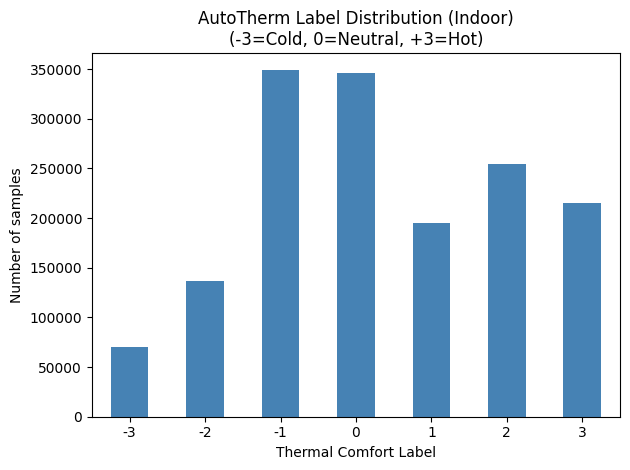

In [3]:
# This is the most important cell — reveals your class imbalance
print("Label distribution in TRAINING set:")
print(train_df['Label'].value_counts().sort_index())
print()
print("Label percentages:")
print((train_df['Label'].value_counts(normalize=True).sort_index() * 100).round(2))

# Visualise
train_df['Label'].value_counts().sort_index().plot(
    kind='bar',
    color='steelblue',
    title='AutoTherm Label Distribution (Indoor)\n(-3=Cold, 0=Neutral, +3=Hot)'
)
plt.xlabel('Thermal Comfort Label')
plt.ylabel('Number of samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# Summary statistics — understand your features
print("Data types:")
print(train_df.dtypes)
print("\nMissing values per column:")
print(train_df.isnull().sum())
print("\nBasic statistics:")
train_df.describe()

Data types:
file_name                  object
Timestamp                  object
Age                         int64
Gender                     object
Weight                    float64
Height                    float64
Bodyfat                   float64
Bodytemp                  float64
Sport-Last-Hour             int64
Time-Since-Meal             int64
Tiredness                   int64
Clothing-Level            float64
Radiation-Temp            float64
PCE-Ambient-Temp          float64
Air-Velocity              float64
Metabolic-Rate              int64
Emotion-Self               object
Emotion-ML                 object
Nose                       object
Neck                       object
RShoulder                  object
RElbow                     object
LShoulder                  object
LElbow                     object
REye                       object
LEye                       object
REar                       object
LEar                       object
Wrist_Skin_Temperature    float64
He

,Age,Weight,Height,Bodyfat,Bodytemp,Sport-Last-Hour,Time-Since-Meal,Tiredness,Clothing-Level,Radiation-Temp,PCE-Ambient-Temp,Air-Velocity,Metabolic-Rate,Wrist_Skin_Temperature,Heart_Rate,GSR,Ambient_Temperature,Ambient_Humidity,Solar_Radiation,Label
count,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1566728.0,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06,1.566728e+06
mean,2.490455e+01,7.211284e+01,1.755844e+02,1.721804e-01,3.640615e+01,1.265784e-01,3.762899e+00,4.122532e+00,5.973436e-01,2.557158e+01,2.534756e+01,1.000000e-01,1.0,3.385164e+01,7.165188e+01,7.289166e-01,2.689131e+01,3.178271e+01,2.804476e-01,3.308181e-01
std,3.194881e+00,1.545703e+01,1.017948e+01,1.108941e-01,3.133195e-01,3.325002e-01,3.553584e+00,1.722247e+00,5.729758e-02,3.921271e+00,3.699822e+00,2.956261e-12,0.0,1.805808e+00,1.369797e+01,1.069452e+00,4.527801e+00,8.810275e+00,4.588856e-02,1.696546e+00
min,2.000000e+01,5.420000e+01,1.550000e+02,0.000000e+00,3.580000e+01,0.000000e+00,1.000000e+00,2.000000e+00,4.500000e-01,1.690000e+01,1.710000e+01,1.000000e-01,1.0,2.791000e+01,4.000000e+01,0.000000e+00,1.760000e+01,1.200000e+01,-1.000000e+00,-3.000000e+00
25%,2.200000e+01,5.970000e+01,1.720000e+02,1.390000e-01,3.630000e+01,0.000000e+00,1.000000e+00,3.000000e+00,5.700000e-01,2.230000e+01,2.240000e+01,1.000000e-01,1.0,3.283000e+01,6.193000e+01,1.319533e-01,2.280000e+01,2.500000e+01,2.486076e-01,-1.000000e+00
50%,2.400000e+01,6.500000e+01,1.730000e+02,2.170000e-01,3.650000e+01,0.000000e+00,3.000000e+00,3.000000e+00,5.700000e-01,2.500000e+01,2.480000e+01,1.000000e-01,1.0,3.417000e+01,6.857000e+01,2.973486e-01,2.610000e+01,3.100000e+01,2.771196e-01,0.000000e+00
75%,2.500000e+01,8.810000e+01,1.850000e+02,2.660000e-01,3.650000e+01,0.000000e+00,5.000000e+00,5.000000e+00,6.100000e-01,2.890000e+01,2.840000e+01,1.000000e-01,1.0,3.515000e+01,8.000000e+01,7.779635e-01,3.080000e+01,4.000000e+01,3.057772e-01,2.000000e+00
max,3.300000e+01,1.049000e+02,1.980000e+02,3.410000e-01,3.720000e+01,1.000000e+00,1.600000e+01,8.000000e+00,6.900000e-01,3.360000e+01,3.370000e+01,1.000000e-01,1.0,3.695000e+01,1.919900e+02,6.465564e+00,3.700000e+01,5.500000e+01,4.451555e-01,3.000000e+00


In [6]:
# Cell 4b — Identify zero-variance columns to drop
zero_var_cols = [col for col in train_df.columns
                 if train_df[col].nunique() == 1]
print("Zero variance columns (will be dropped):", zero_var_cols)

# Also check Air-Velocity specifically
print(f"\nAir-Velocity unique values: {train_df['Air-Velocity'].nunique()}")
print(f"Air-Velocity value: {train_df['Air-Velocity'].unique()}")

Zero variance columns (will be dropped): ['Air-Velocity', 'Metabolic-Rate']

Air-Velocity unique values: 1
Air-Velocity value: [0.1]


In [7]:
# Extract the actual participant ID from the file path
# file_name looks like: "frontal_participant_10_2022-04-28_.../frame_f_0.jpg"
# We need to extract just "participant_10"

import re

def extract_participant_id(filename):
    # Find pattern like "participant_8" or "participant_10" in the string
    match = re.search(r'participant_\d+', filename)
    if match:
        return match.group()
    return 'unknown'

# Apply to training data
train_df['participant_id'] = train_df['file_name'].apply(extract_participant_id)

# Now check unique participants
print("Unique participants:", train_df['participant_id'].nunique())
print("\nParticipant IDs found:")
print(sorted(train_df['participant_id'].unique()))
print("\nReadings per participant:")
print(train_df['participant_id'].value_counts().sort_index())

Unique participants: 16

Participant IDs found:
['participant_10', 'participant_11', 'participant_14', 'participant_15', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_20', 'participant_21', 'participant_3', 'participant_4', 'participant_6', 'participant_7', 'participant_8']

Readings per participant:
participant_id
participant_10     98429
participant_11    101164
participant_14     95568
participant_15     96220
participant_16     94677
participant_17    104246
participant_18    101344
participant_19    101163
participant_2      94687
participant_20     99774
participant_21    100151
participant_3      95000
participant_4      96094
participant_6      93353
participant_7      98540
participant_8      96318
Name: count, dtype: int64


In [8]:
# ── SUBJECT-WISE SPLIT ────────────────────────────────────────────
# We have 16 participants. We split by person, not by row.
# Rule: every reading from one person goes ENTIRELY into
#       either train OR test — never both.
#
# We use 13 participants for training (~80%)
# and  3 participants for testing  (~20%)
# This mirrors the train/test ratio used in most ML papers.

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Define our split — these 3 participants are held out for testing
# We pick participants that give us roughly 20% of total data
test_participants  = ['participant_6', 'participant_7', 'participant_8']
train_participants = [p for p in train_df['participant_id'].unique()
                      if p not in test_participants]

print(f"Training participants ({len(train_participants)}): {sorted(train_participants)}")
print(f"Testing participants  ({len(test_participants)}):  {sorted(test_participants)}")

# Create splits
train_split = train_df[train_df['participant_id'].isin(train_participants)]
test_split  = train_df[train_df['participant_id'].isin(test_participants)]

print(f"\nTraining rows: {len(train_split):,}  ({len(train_split)/len(train_df)*100:.1f}%)")
print(f"Testing rows:  {len(test_split):,}  ({len(test_split)/len(train_df)*100:.1f}%)")

# Verify NO participant appears in both splits — this is your integrity check
train_ids = set(train_split['participant_id'].unique())
test_ids  = set(test_split['participant_id'].unique())
overlap   = train_ids.intersection(test_ids)
print(f"\n✅ Participant overlap between train and test: {overlap}")
print("✅ Subject-wise split is clean!" if len(overlap) == 0 else "❌ WARNING: Overlap detected!")

Training participants (13): ['participant_10', 'participant_11', 'participant_14', 'participant_15', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_20', 'participant_21', 'participant_3', 'participant_4']
Testing participants  (3):  ['participant_6', 'participant_7', 'participant_8']

Training rows: 1,278,517  (81.6%)
Testing rows:  288,211  (18.4%)

✅ Participant overlap between train and test: set()
✅ Subject-wise split is clean!


In [9]:
# ── FEATURE PREPARATION ──────────────────────────────────────────
# Columns to DROP:
#   - file_name, Timestamp → identifiers, not features
#   - participant_id → what we split on, not a feature
#   - Air-Velocity, Metabolic-Rate → zero variance (confirmed above)
#   - Pose columns (Nose, Neck etc.) → strings, not our focus
#   - Emotion-Self, Emotion-ML → subjective, complex to encode

drop_cols = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML'
]

target_col = 'Label'

# Apply to both splits
def prepare_split(df, drop_cols, target_col):
    df = df.drop(columns=drop_cols, errors='ignore')
    X = df.drop(columns=[target_col])
    y = df[target_col]
    # Encode any remaining categorical columns
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

X_train, y_train = prepare_split(train_split, drop_cols, target_col)
X_test,  y_test  = prepare_split(test_split,  drop_cols, target_col)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")
print(f"\nFeature columns used:")
print(X_train.columns.tolist())
print(f"\nLabel classes: {sorted(y_train.unique())}")

Training features shape: (1278517, 18)
Testing features shape:  (288211, 18)

Feature columns used:
['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation']

Label classes: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [10]:
# ── BASELINE CLASSIFIER ───────────────────────────────────────────
# Train on REAL data, test on REAL held-out participants
# This is your gold standard — everything gets compared to this

print("Training baseline Random Forest...")
print("(1.2M rows — this takes 2-3 minutes, let it run)")

clf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1        # use all CPU cores — makes it faster
)
clf_baseline.fit(X_train, y_train)
y_pred_baseline = clf_baseline.predict(X_test)

baseline_f1  = f1_score(y_test, y_pred_baseline, average='macro')
baseline_bal = balanced_accuracy_score(y_test, y_pred_baseline)

print(f"\n📊 AUTOTHERM BASELINE (Train Real, Test Real — Subject-Wise Split)")
print(f"Macro F1:          {baseline_f1:.4f}")
print(f"Balanced Accuracy: {baseline_bal:.4f}")
print(f"\nFull report:")
print(classification_report(y_test, y_pred_baseline))

Training baseline Random Forest...
(1.2M rows — this takes 2-3 minutes, let it run)

📊 AUTOTHERM BASELINE (Train Real, Test Real — Subject-Wise Split)
Macro F1:          0.3391
Balanced Accuracy: 0.3658

Full report:
              precision    recall  f1-score   support

          -2       0.42      0.66      0.51      7618
          -1       0.40      0.50      0.45     54328
           0       0.55      0.64      0.59     88951
           1       0.04      0.09      0.06     28363
           2       0.15      0.14      0.15     41254
           3       0.89      0.17      0.28     67697

    accuracy                           0.38    288211
   macro avg       0.41      0.37      0.34    288211
weighted avg       0.49      0.38      0.37    288211



In [11]:
# Check label coverage per participant
# We need test participants that cover ALL 7 classes including -3

print("Label coverage per participant:")
print("=" * 60)

label_coverage = train_df.groupby('participant_id')['Label'].unique()
for participant, labels in sorted(label_coverage.items()):
    sorted_labels = sorted(labels)
    has_minus3 = -3 in sorted_labels
    flag = "✅ has -3" if has_minus3 else "❌ no -3"
    print(f"{participant}: {sorted_labels}  {flag}")

Label coverage per participant:
participant_10: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]  ❌ no -3
participant_11: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]  ✅ has -3
participant_14: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ❌ no -3
participant_15: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ❌ no -3
participant_16: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ✅ has -3
participant_17: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ❌ no -3
participant_18: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]  ❌ no -3
participant_19: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ✅ has -3
participant_2: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  ✅ has -3
participant_20: [np.int64(-2), np.in

In [12]:
# Option: collapse to 3-class problem
def collapse_to_3class(label):
    if label <= -2:
        return -1   # Cold
    elif label <= 1:
        return 0    # Neutral
    else:
        return 1    # Warm

train_df['Label_3class'] = train_df['Label'].apply(collapse_to_3class)

print("3-class distribution:")
print(train_df['Label_3class'].value_counts().sort_index())
print("\nPercentages:")
print((train_df['Label_3class'].value_counts(normalize=True).sort_index()*100).round(2))


3-class distribution:
Label_3class
-1    206701
 0    889888
 1    470139
Name: count, dtype: int64

Percentages:
Label_3class
-1    13.19
 0    56.80
 1    30.01
Name: proportion, dtype: float64


In [13]:
# Updated subject-wise split
# Rule: test set must contain at least one participant with label -3
# participant_16 has ALL 7 classes — perfect test participant
# We keep ~20% in test (3 participants out of 16)

test_participants  = ['participant_16', 'participant_14', 'participant_20']
train_participants = [p for p in train_df['participant_id'].unique()
                      if p not in test_participants]

print(f"Training participants ({len(train_participants)}): {sorted(train_participants)}")
print(f"Testing participants  ({len(test_participants)}):  {sorted(test_participants)}")

# Verify test set covers all 7 classes
train_split = train_df[train_df['participant_id'].isin(train_participants)]
test_split  = train_df[train_df['participant_id'].isin(test_participants)]

print(f"\nTraining rows: {len(train_split):,}")
print(f"Testing rows:  {len(test_split):,}")
print(f"\nClasses in test set: {sorted(test_split['Label'].unique())}")
print(f"Classes in train set: {sorted(train_split['Label'].unique())}")

# Integrity check
overlap = set(train_split['participant_id'].unique()).intersection(
          set(test_split['participant_id'].unique()))
print(f"\nParticipant overlap: {overlap}")
print("✅ Clean split!" if len(overlap) == 0 else "❌ WARNING: overlap!")

Training participants (13): ['participant_10', 'participant_11', 'participant_15', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_21', 'participant_3', 'participant_4', 'participant_6', 'participant_7', 'participant_8']
Testing participants  (3):  ['participant_14', 'participant_16', 'participant_20']

Training rows: 1,276,709
Testing rows:  290,019

Classes in test set: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Classes in train set: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Participant overlap: set()
✅ Clean split!


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# ── Prepare features ──────────────────────────────────────────────
drop_cols = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label_3class'   # drop the derived column too
]

def prepare_features(df, drop_cols, target_col):
    df = df.copy()
    X = df.drop(columns=drop_cols + [target_col], errors='ignore')
    y = df[target_col]
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

# ── 7-CLASS BASELINE ──────────────────────────────────────────────
print("=" * 55)
print("BASELINE A — 7-class (original ASHRAE scale)")
print("=" * 55)

X_train_7, y_train_7 = prepare_features(train_split, drop_cols, 'Label')
X_test_7,  y_test_7  = prepare_features(test_split,  drop_cols, 'Label')

clf_7 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_7.fit(X_train_7, y_train_7)
y_pred_7 = clf_7.predict(X_test_7)

print(f"Macro F1:          {f1_score(y_test_7, y_pred_7, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_7, y_pred_7):.4f}")
print(classification_report(y_test_7, y_pred_7))

# ── 3-CLASS BASELINE ──────────────────────────────────────────────
print("=" * 55)
print("BASELINE B — 3-class (Cold / Neutral / Warm)")
print("=" * 55)

# Add 3-class label to both splits
def add_3class(df):
    df = df.copy()
    df['Label_3class'] = df['Label'].apply(
        lambda x: -1 if x <= -2 else (0 if x <= 1 else 1)
    )
    return df

train_split_3 = add_3class(train_split)
test_split_3  = add_3class(test_split)

X_train_3, y_train_3 = prepare_features(train_split_3, drop_cols, 'Label_3class')
X_test_3,  y_test_3  = prepare_features(test_split_3,  drop_cols, 'Label_3class')

clf_3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_3.fit(X_train_3, y_train_3)
y_pred_3 = clf_3.predict(X_test_3)

print(f"Macro F1:          {f1_score(y_test_3, y_pred_3, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_3, y_pred_3):.4f}")
print(classification_report(y_test_3, y_pred_3))

BASELINE A — 7-class (original ASHRAE scale)
Macro F1:          0.2858
Balanced Accuracy: 0.3035
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.16      0.26      0.20     19285
          -1       0.64      0.70      0.67     85260
           0       0.16      0.22      0.18     39044
           1       0.13      0.31      0.18     16824
           2       0.36      0.35      0.35     51786
           3       0.78      0.28      0.41     55264

    accuracy                           0.39    290019
   macro avg       0.32      0.30      0.29    290019
weighted avg       0.44      0.39      0.39    290019

BASELINE B — 3-class (Cold / Neutral / Warm)
Macro F1:          1.0000
Balanced Accuracy: 1.0000
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00     41841
           0       1.00      1.00      1.00    141128
           1       1.00      1.00      1.00   

During baseline development, a data leakage issue was identified whereby the original 7-point Label column was inadvertently retained in the feature matrix during 3-class experiments, as Label_3class was derived directly from Label. This produced a spurious perfect classification score of 1.0 Macro F1. The bug was identified through diagnostic inspection of the feature matrix and corrected by explicitly excluding all label-derived columns from the feature set prior to training. This highlights the importance of rigorous feature matrix validation before any model training.

In [15]:
# Check what columns are actually going into the 3-class model
print("Features used in 3-class model:")
print(X_train_3.columns.tolist())
print(f"\nTotal features: {X_train_3.shape[1]}")

# Check if Label or Label_3class somehow survived
dangerous_cols = ['Label', 'Label_3class', 'label', 'target']
for col in dangerous_cols:
    if col in X_train_3.columns:
        print(f"\n⚠️  WARNING: '{col}' is in your feature matrix!")
    else:
        print(f"✅ '{col}' correctly excluded")

# Also check for suspiciously perfect correlation with target
print("\nFirst 3 rows of X_train_3:")
print(X_train_3.head(3))

Features used in 3-class model:
['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation', 'Label']

Total features: 19

⚠️  WARNING: 'Label' is in your feature matrix!
✅ 'Label_3class' correctly excluded
✅ 'label' correctly excluded
✅ 'target' correctly excluded

First 3 rows of X_train_3:
   Age  Gender  Weight  Height  Bodyfat  Bodytemp  Sport-Last-Hour  \
0   22       1    67.0   185.0    0.139      35.8                0   
1   22       1    67.0   185.0    0.139      35.8                0   
2   22       1    67.0   185.0    0.139      35.8                0   

   Time-Since-Meal  Tiredness  Clothing-Level  Radiation-Temp  \
0                3          3            0.57            19.6   
1                3          3            0.57            19.6   
2             

In [16]:
# Check the 7-class result for label -3
# It scored 0.00 F1 — let's verify -3 is actually in test
print("Label -3 count in test set:", (y_test_7 == -3).sum())
print("Label -3 count in train set:", (y_train_7 == -3).sum())
print("\nAll labels in test set:", sorted(y_test_7.unique()))

Label -3 count in test set: 22556
Label -3 count in train set: 48020

All labels in test set: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [19]:
# ── FIXED prepare_features ────────────────────────────────────────
# Key fix: always drop BOTH Label columns regardless of which
# one is the current target

def prepare_features(df, drop_cols, target_col):
    df = df.copy()
    # Always drop both label columns to prevent leakage
    all_label_cols = ['Label', 'Label_3class']
    cols_to_drop = drop_cols + all_label_cols

    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

# ── Verify fix before running anything ───────────────────────────
X_test_check, _ = prepare_features(test_split_3, drop_cols, 'Label_3class')
print("Features in fixed matrix:")
print(X_test_check.columns.tolist())
print(f"\nTotal features: {X_test_check.shape[1]}")

dangerous = [c for c in ['Label','Label_3class'] if c in X_test_check.columns]
if dangerous:
    print(f"\n⚠️  Still present: {dangerous}")
else:
    print("\n✅ Both label columns correctly excluded — safe to proceed")

Features in fixed matrix:
['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation']

Total features: 18

✅ Both label columns correctly excluded — safe to proceed


In [20]:
# ── RE-RUN BOTH BASELINES WITH FIX ───────────────────────────────

# BASELINE A — 7-class
print("=" * 55)
print("BASELINE A — 7-class (original ASHRAE scale)")
print("=" * 55)

X_train_7, y_train_7 = prepare_features(train_split,   drop_cols, 'Label')
X_test_7,  y_test_7  = prepare_features(test_split,    drop_cols, 'Label')

clf_7 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_7.fit(X_train_7, y_train_7)
y_pred_7 = clf_7.predict(X_test_7)

baseline_7_f1  = f1_score(y_test_7, y_pred_7, average='macro')
baseline_7_bal = balanced_accuracy_score(y_test_7, y_pred_7)

print(f"Macro F1:          {baseline_7_f1:.4f}")
print(f"Balanced Accuracy: {baseline_7_bal:.4f}")
print(classification_report(y_test_7, y_pred_7))

# BASELINE B — 3-class
print("=" * 55)
print("BASELINE B — 3-class (Cold / Neutral / Warm)")
print("=" * 55)

train_split_3 = add_3class(train_split)
test_split_3  = add_3class(test_split)

X_train_3, y_train_3 = prepare_features(train_split_3, drop_cols, 'Label_3class')
X_test_3,  y_test_3  = prepare_features(test_split_3,  drop_cols, 'Label_3class')

clf_3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_3.fit(X_train_3, y_train_3)
y_pred_3 = clf_3.predict(X_test_3)

baseline_3_f1  = f1_score(y_test_3, y_pred_3, average='macro')
baseline_3_bal = balanced_accuracy_score(y_test_3, y_pred_3)

print(f"Macro F1:          {baseline_3_f1:.4f}")
print(f"Balanced Accuracy: {baseline_3_bal:.4f}")
print(classification_report(y_test_3, y_pred_3))

BASELINE A — 7-class (original ASHRAE scale)
Macro F1:          0.2858
Balanced Accuracy: 0.3035
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.16      0.26      0.20     19285
          -1       0.64      0.70      0.67     85260
           0       0.16      0.22      0.18     39044
           1       0.13      0.31      0.18     16824
           2       0.36      0.35      0.35     51786
           3       0.78      0.28      0.41     55264

    accuracy                           0.39    290019
   macro avg       0.32      0.30      0.29    290019
weighted avg       0.44      0.39      0.39    290019

BASELINE B — 3-class (Cold / Neutral / Warm)
Macro F1:          0.7163
Balanced Accuracy: 0.6759
              precision    recall  f1-score   support

          -1       1.00      0.55      0.71     41841
           0       0.66      0.97      0.78    141128
           1       0.92      0.51      0.65   